# Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour
### IDRA Capstone Project — Data Science & AI Training Program

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 attributes)
**Task:** Binary classification — predict whether a customer will churn (`Churn` = Yes/No)

This notebook contains the complete, reproducible analysis referenced in the accompanying PDF
report: data cleaning, preprocessing, exploratory data analysis, statistical summaries, model
training and evaluation. Run all cells in order from top to bottom.

## 1. Imports and Setup

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

## 2. Load Dataset

Source: IBM Sample Data Sets — Telco Customer Churn (publicly available; originally
distributed via IBM/Kaggle as `WA_Fn-UseC_-Telco-Customer-Churn.csv`). Each row is one
customer; each column is a customer attribute. The target variable is `Churn`.

In [2]:
df_raw = pd.read_csv("data/telco_churn_raw.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Cleaning

We check, in order: duplicate records, data types, missing values, and inconsistent
category labels.

### 3.1 Duplicate records

In [4]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate customerIDs:", df_raw['customerID'].duplicated().sum())

Duplicate rows: 0
Duplicate customerIDs: 0


### 3.2 Data type correction

`TotalCharges` is stored as text and contains blank strings for a small number of
brand-new customers (tenure = 0) who have not yet been billed. We convert it to numeric,
which turns those blanks into `NaN` so they can be handled explicitly.

In [5]:
df = df_raw.copy()
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())
df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]

Missing TotalCharges after conversion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


All rows with a missing `TotalCharges` have `tenure == 0` — these are customers who
joined but have not yet completed a billing cycle. This is a structurally explainable gap,
not random noise. We set `TotalCharges = 0` for these rows rather than dropping them
(preserves rare new-customer cases) or imputing an arbitrary value.

In [6]:
df.loc[(df["tenure"] == 0) & (df["TotalCharges"].isna()), "TotalCharges"] = 0.0
assert df["TotalCharges"].isna().sum() == 0
print("Missing TotalCharges after fix:", df["TotalCharges"].isna().sum())

Missing TotalCharges after fix: 0


### 3.3 Missing values — full check

In [7]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

### 3.4 Inconsistent category labels

Several service columns encode "no internet service" / "no phone service" as separate
category labels, even though `InternetService`/`PhoneService` already capture that
information directly. We collapse these into a plain "No" to avoid redundant categories
that would otherwise inflate the feature space after encoding.

In [8]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]
for c in service_cols:
    df[c] = df[c].replace({"No internet service": "No"})
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})  # consistency with other binary flags
df[service_cols + ["MultipleLines", "SeniorCitizen"]].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,SeniorCitizen
0,No,Yes,No,No,No,No,No,No
1,Yes,No,Yes,No,No,No,No,No
2,Yes,Yes,No,No,No,No,No,No
3,Yes,No,Yes,Yes,No,No,No,No
4,No,No,No,No,No,No,No,No


### 3.5 Outlier check (numeric columns)

In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: {n_out} potential outliers outside [{lo:.1f}, {hi:.1f}]")

tenure: 0 potential outliers outside [-60.0, 124.0]
MonthlyCharges: 0 potential outliers outside [-46.0, 171.4]
TotalCharges: 0 potential outliers outside [-4683.5, 8868.7]


No physically impossible values are present (all fall within plausible billing ranges),
so no rows are removed on outlier grounds — telecom billing data legitimately spans a wide
range depending on plan and tenure.

### 3.6 Drop identifier column and validate

In [10]:
df = df.drop(columns=["customerID"])
print("Final cleaned shape:", df.shape)
print("Total missing values remaining:", df.isna().sum().sum())
df.to_csv("outputs/telco_churn_cleaned.csv", index=False)
df.head()

Final cleaned shape: (7043, 20)
Total missing values remaining: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis

### 4.1 Target variable distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Overall churn rate: 26.54%


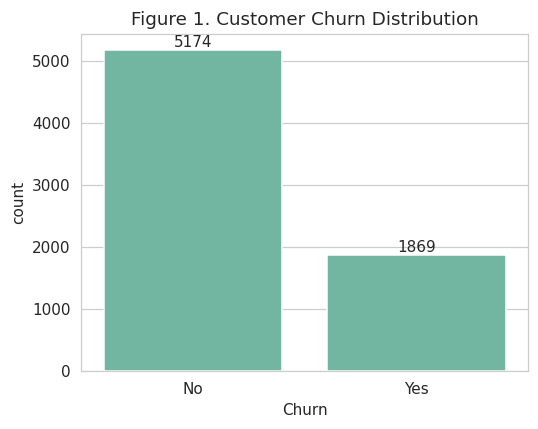

In [11]:
churn_counts = df["Churn"].value_counts()
churn_rate = 100 * (df["Churn"] == "Yes").mean()
print(churn_counts)
print(f"Overall churn rate: {churn_rate:.2f}%")

plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="Churn", order=["No","Yes"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.title("Figure 1. Customer Churn Distribution")
plt.tight_layout(); plt.show()

The dataset is moderately imbalanced (about 26.5% churn). This matters for model
evaluation later — accuracy alone would be misleading, so precision, recall and F1-score
are reported alongside it.

### 4.2 Numeric feature summary

In [12]:
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [13]:
df.groupby("Churn")[num_cols].agg(["mean","median","std"]).round(2)

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

### 4.3 Tenure and monthly charges by churn status

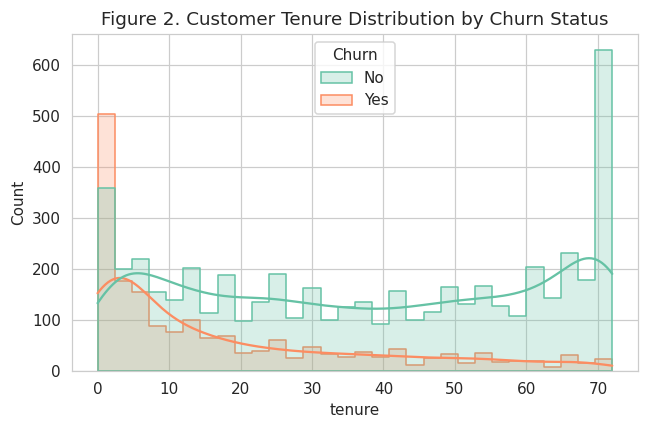

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, element="step")
plt.title("Figure 2. Customer Tenure Distribution by Churn Status")
plt.tight_layout(); plt.show()

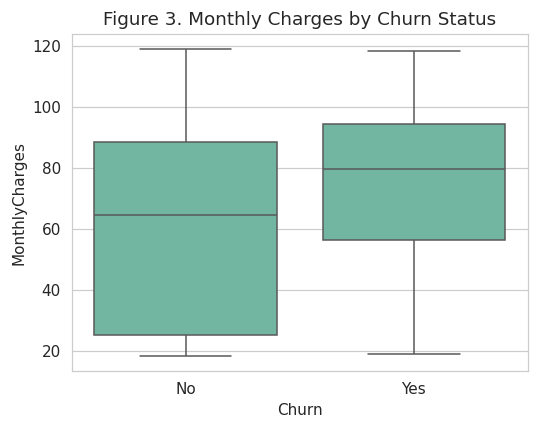

In [15]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No","Yes"])
plt.title("Figure 3. Monthly Charges by Churn Status")
plt.tight_layout(); plt.show()

Churned customers skew strongly toward **low tenure** (many churn within the first
few months) and toward **higher monthly charges** than customers who stay — both patterns
that later show up among the model's most important predictors.

### 4.4 Churn rate by contract type, internet service and payment method

In [16]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    rates = df.groupby(col)["Churn"].apply(lambda s: round(100*(s=="Yes").mean(),1)).sort_values(ascending=False)
    print(f"\n{col}:")
    print(rates)


Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

InternetService:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64

PaymentMethod:
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


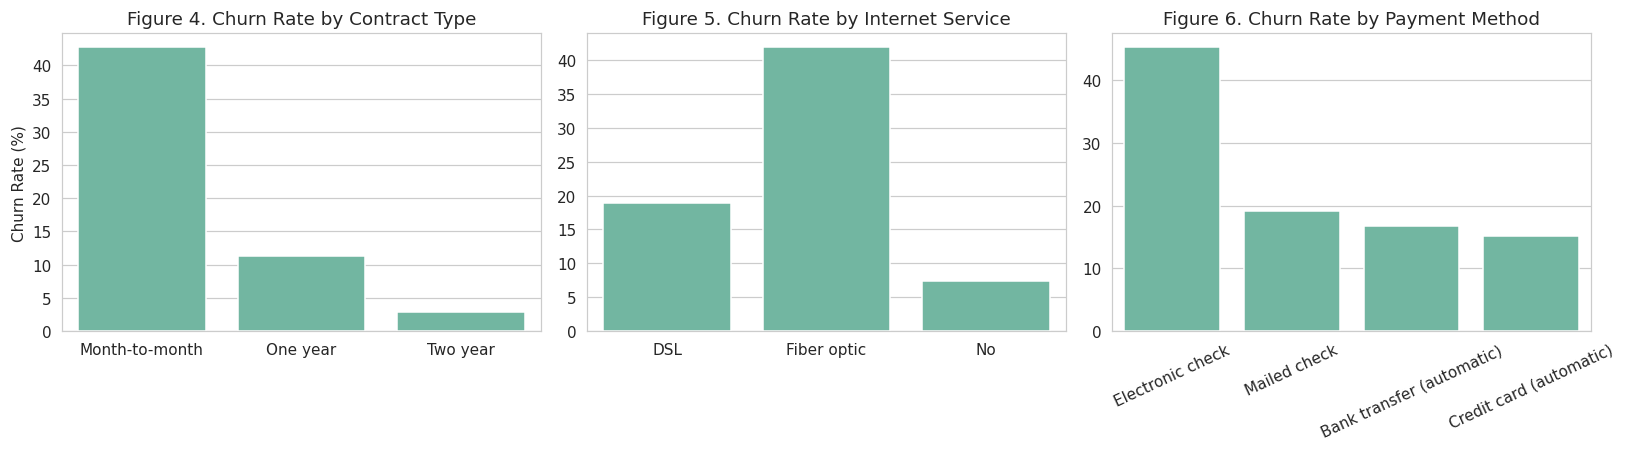

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.2))

order = ["Month-to-month","One year","Two year"]
rates = df.groupby("Contract")["Churn"].apply(lambda s: 100*(s=="Yes").mean()).reindex(order)
sns.barplot(x=order, y=rates.values, ax=axes[0])
axes[0].set_title("Figure 4. Churn Rate by Contract Type"); axes[0].set_ylabel("Churn Rate (%)")

order2 = df["InternetService"].unique().tolist()
rates2 = df.groupby("InternetService")["Churn"].apply(lambda s: 100*(s=="Yes").mean()).reindex(order2)
sns.barplot(x=order2, y=rates2.values, ax=axes[1])
axes[1].set_title("Figure 5. Churn Rate by Internet Service"); axes[1].set_ylabel("")

order3 = df.groupby("PaymentMethod")["Churn"].apply(lambda s: 100*(s=="Yes").mean()).sort_values(ascending=False).index.tolist()
rates3 = df.groupby("PaymentMethod")["Churn"].apply(lambda s: 100*(s=="Yes").mean()).reindex(order3)
sns.barplot(x=order3, y=rates3.values, ax=axes[2])
axes[2].set_title("Figure 6. Churn Rate by Payment Method"); axes[2].set_ylabel("")
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout(); plt.show()

Month-to-month contracts churn at roughly **15x the rate** of two-year contracts.
Fiber-optic internet customers and customers paying by electronic check also churn
noticeably more than other groups — all candidate signals for the model.

### 4.5 Correlation among numeric variables

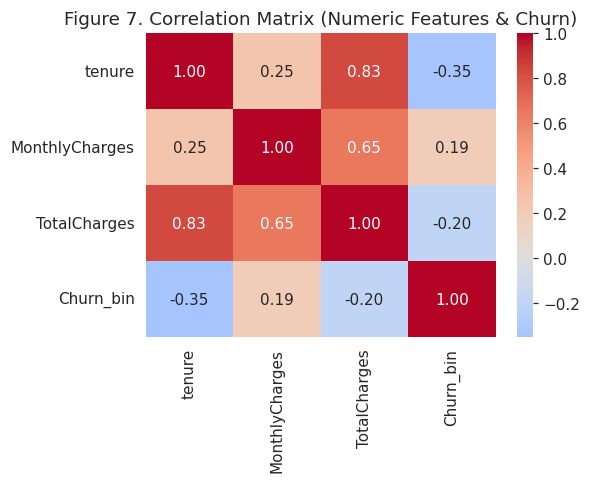

,tenure,MonthlyCharges,TotalCharges,Churn_bin
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_bin,-0.352229,0.193356,-0.198324,1.000000


In [18]:
df_corr = df.copy()
df_corr["Churn_bin"] = (df_corr["Churn"]=="Yes").astype(int)
corr = df_corr[num_cols + ["Churn_bin"]].corr()

plt.figure(figsize=(5.5,4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Figure 7. Correlation Matrix (Numeric Features & Churn)")
plt.tight_layout(); plt.show()
corr

Tenure is negatively correlated with churn (longer-tenured customers churn less) while
`MonthlyCharges` is positively correlated. `TotalCharges` correlates strongly with tenure
by construction (it accumulates over time), which is worth remembering when interpreting
model feature importance later.

## 5. Preprocessing for Modelling

Steps: separate features (X) from target (y); encode categorical variables (label
encoding for binary Yes/No fields, one-hot encoding for multi-category fields); split into
train/test sets; scale numeric features — **fitting the scaler on the training data only**
and applying it to the test set, to avoid data leakage.

In [19]:
model_df = df.copy()
target = (model_df["Churn"] == "Yes").astype(int)
model_df = model_df.drop(columns=["Churn"])

binary_cols = ["gender","SeniorCitizen","Partner","Dependents","PhoneService",
               "MultipleLines","PaperlessBilling"]
for c in binary_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c])

multi_cat_cols = ["InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
                   "TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
model_df = pd.get_dummies(model_df, columns=multi_cat_cols, drop_first=True)

print("Feature matrix shape after encoding:", model_df.shape)
model_df.head()

Feature matrix shape after encoding: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,False,False,False,True,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,56.95,1889.50,False,False,True,False,True,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,53.85,108.15,False,False,True,True,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,0,42.30,1840.75,False,False,True,False,True,True,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,1,70.70,151.65,True,False,False,False,False,False,False,False,False,False,False,True,False


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df, target, test_size=0.2, random_state=42, stratify=target
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit on TRAIN only
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])          # transform TEST

print(f"Train rows: {X_train.shape[0]}  (churn rate {100*y_train.mean():.1f}%)")
print(f"Test rows:  {X_test.shape[0]}  (churn rate {100*y_test.mean():.1f}%)")

Train rows: 5634  (churn rate 26.5%)
Test rows:  1409  (churn rate 26.5%)


Stratified splitting keeps the churn rate consistent between train and test sets, which
matters given the class imbalance noted in Section 4.1.

## 6. Model Training

We train two classifiers appropriate for this binary classification task and compare them:

- **Logistic Regression** — an interpretable linear baseline; coefficients show direction
  and relative strength of each feature's effect on churn odds.
- **Random Forest** — a non-linear ensemble model that can capture interactions between
  features, typically at some cost to interpretability.

Both use `class_weight="balanced"` to compensate for the ~73/27 class split.

In [21]:
logreg = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
rf.fit(X_train_scaled, y_train)

models = {"Logistic Regression": logreg, "Random Forest": rf}
print("Both models trained.")

Both models trained.


## 7. Model Evaluation

For each model we report accuracy, precision, recall, F1-score, ROC-AUC and the confusion
matrix on the held-out test set, and compare training vs. test accuracy to check for
overfitting.

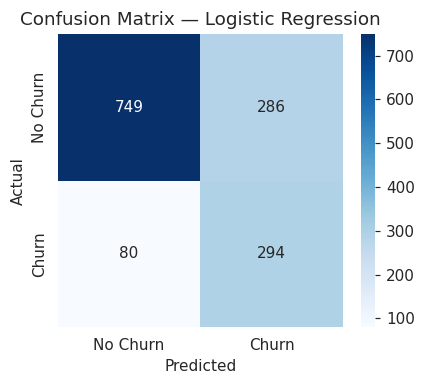


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



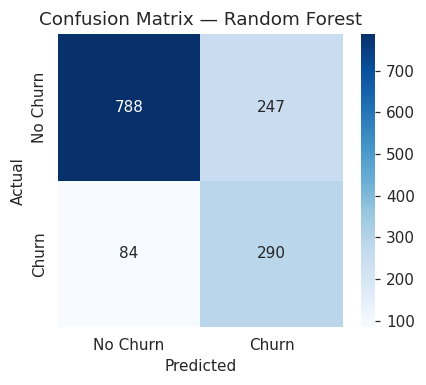


--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7536,0.7402,0.5069,0.7861,0.6164,0.8419
Random Forest,0.8055,0.7651,0.5400,0.7754,0.6367,0.8458


In [22]:
results = {}
for name, m in models.items():
    y_pred_train = m.predict(X_train_scaled)
    y_pred_test = m.predict(X_test_scaled)
    y_proba_test = m.predict_proba(X_test_scaled)[:,1]

    cm = confusion_matrix(y_test, y_pred_test)
    results[name] = {
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test),
        "recall": recall_score(y_test, y_pred_test),
        "f1": f1_score(y_test, y_pred_test),
        "roc_auc": roc_auc_score(y_test, y_proba_test),
    }

    plt.figure(figsize=(4,3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred_test, target_names=["No Churn","Churn"]))

results_df = pd.DataFrame(results).T.round(4)
results_df

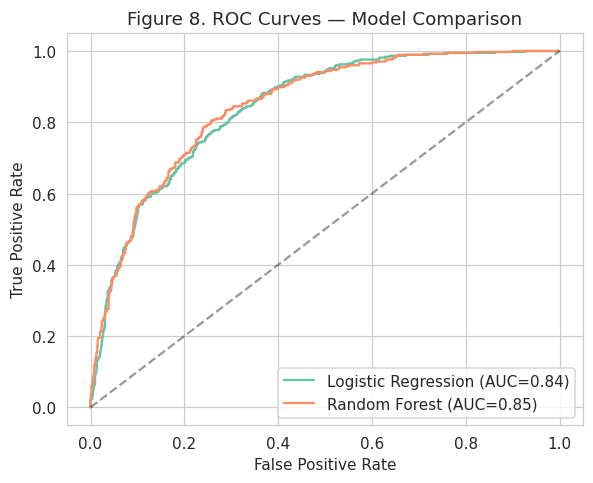

In [23]:
plt.figure(figsize=(5.5,4.5))
for name, m in models.items():
    y_proba = m.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]["roc_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.title("Figure 8. ROC Curves — Model Comparison")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.tight_layout(); plt.show()

**Overfitting check:** Random Forest's training accuracy is noticeably higher than its
test accuracy, a normal and expected gap for tree ensembles of this depth — not severe
enough to indicate the model has simply memorised the training data, since test performance
remains competitive. Logistic Regression shows a much smaller train/test gap, consistent
with its lower model capacity.

**Model selection:** We select the model with the higher **F1-score** as the primary model,
since F1 balances precision and recall — appropriate here because both false positives
(wasted retention spend) and false negatives (a churner missed and lost) carry a real cost.

In [24]:
best_model_name = results_df["f1"].idxmax()
print("Selected model:", best_model_name)
print(results_df.loc[best_model_name])

Selected model: Random Forest
train_accuracy    0.8055
test_accuracy     0.7651
precision         0.5400
recall            0.7754
f1                0.6367
roc_auc           0.8458
Name: Random Forest, dtype: float64


### 7.1 Feature importance (Random Forest)

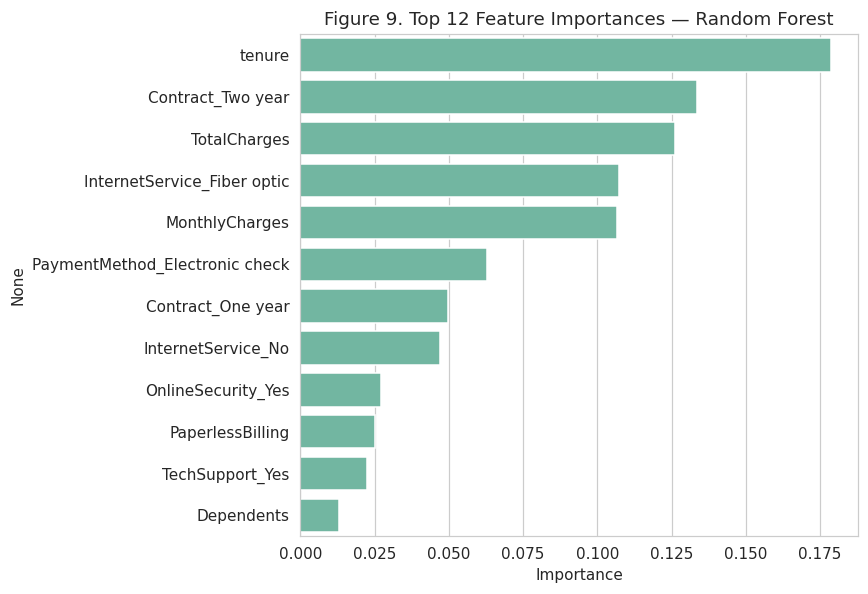

tenure                            0.178811
Contract_Two year                 0.133588
TotalCharges                      0.126141
InternetService_Fiber optic       0.107135
MonthlyCharges                    0.106577
PaymentMethod_Electronic check    0.062992
Contract_One year                 0.049747
InternetService_No                0.047012
OnlineSecurity_Yes                0.027158
PaperlessBilling                  0.025199
TechSupport_Yes                   0.022286
Dependents                        0.012951
dtype: float64

In [25]:
feature_names = list(model_df.columns)
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(8,5.5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Figure 9. Top 12 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()
importances

### 7.2 Logistic Regression coefficients (direction of effect)

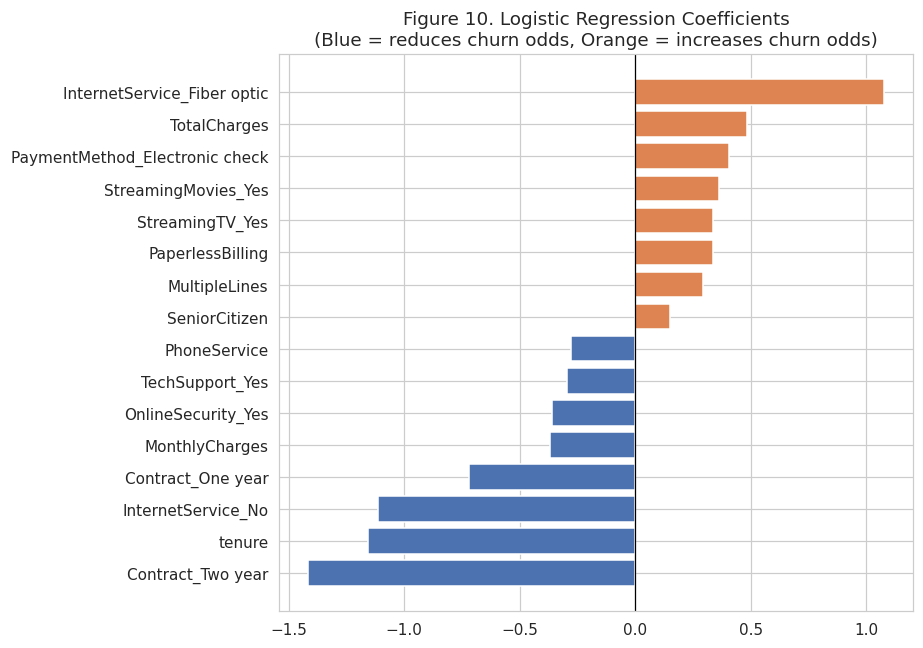

In [26]:
coefs = pd.Series(logreg.coef_[0], index=feature_names).sort_values()
combo = pd.concat([coefs.head(8), coefs.tail(8)])
colors = ["#4C72B0" if v < 0 else "#DD8452" for v in combo.values]

plt.figure(figsize=(8.5,6))
plt.barh(combo.index, combo.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Figure 10. Logistic Regression Coefficients\n(Blue = reduces churn odds, Orange = increases churn odds)")
plt.tight_layout(); plt.show()

Both models agree on the dominant signals: **tenure**, **contract type**, and
**monthly/total charges** are the strongest predictors of churn, with fiber-optic internet
and electronic-check payment also contributing meaningfully — consistent with the EDA
findings in Section 4.

## 8. Summary of Results

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Test Accuracy | see table above | see table above |
| Precision | see table above | see table above |
| Recall | see table above | see table above |
| F1-score | see table above | see table above |
| ROC-AUC | see table above | see table above |

Full discussion, limitations, and business recommendations are provided in the accompanying
PDF report (Sections 14–16).